# Explanatory Data Analysis 
# Data Cleaning 
# Data Preprocessing 

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

## Load dataset

In [55]:
data_path = 'diabetic_data.csv'
df = pd.read_csv(data_path)

In [74]:
# Load mapping file
mapping_path = 'IDS_mapping.csv'
mapping_df = pd.read_csv(mapping_path)



## Unique values

checking unique values to find what is used as NAN is dataset

In [57]:
print("\nUnique values per column:")
for column in df.columns:
    unique_vals = df[column].unique()
    print(f"{column}: {unique_vals[:100]}{'...' if len(unique_vals) > 100 else ''}")



Unique values per column:
encounter_id: [2278392  149190   64410  500364   16680   35754   55842   63768   12522
   15738   28236   36900   40926   42570   62256   73578   77076   84222
   89682  148530  150006  150048  182796  183930  216156  221634  236316
  248916  250872  252822  253380  253722  260166  293058  293118  325848
  325866  326028  358776  377268  383430  419304  421194  449142  450210
  464994  486156  498030  537834  544194  550098  584136  590346  591996
  604188  623880  630342  654918  669954  676416  676422  679722  682494
  685086  712350  713268  715086  792402  796152  833424  870294  881016
  922080  927786  955884  961464  964548 1050294 1069716 1070256 1072554
 1077924 1079592 1110420 1115640 1119858 1136472 1139226 1157454 1157574
 1161024 1185942 1186980 1193868 1194678 1195056 1195548 1212006 1257282
 1260216]...
patient_nbr: [  8222157  55629189  86047875  82442376  42519267  82637451  84259809
 114882984  48330783  63555939  89869032  77391171  8550490

In [58]:
# Replace '?' with NaN, since we found out that '?' is used as NAN
df.replace('?', pd.NA, inplace=True)

## Display basic info

In [59]:
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()

Dataset Shape: (101766, 50)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures  

## Display first few rows

In [60]:
print("\nFirst 5 rows:")
print(df.head())



First 5 rows:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)   <NA>   
1        149190     55629189        Caucasian  Female  [10-20)   <NA>   
2         64410     86047875  AfricanAmerican  Female  [20-30)   <NA>   
3        500364     82442376        Caucasian    Male  [30-40)   <NA>   
4         16680     42519267        Caucasian    Male  [40-50)   <NA>   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No      

## Check for missing values

In [61]:
missing_values = df.isnull().sum().sort_values(ascending=False)
print("\nMissing Values:")
print(missing_values[missing_values > 0])



Missing Values:
weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


## Visualize missing data

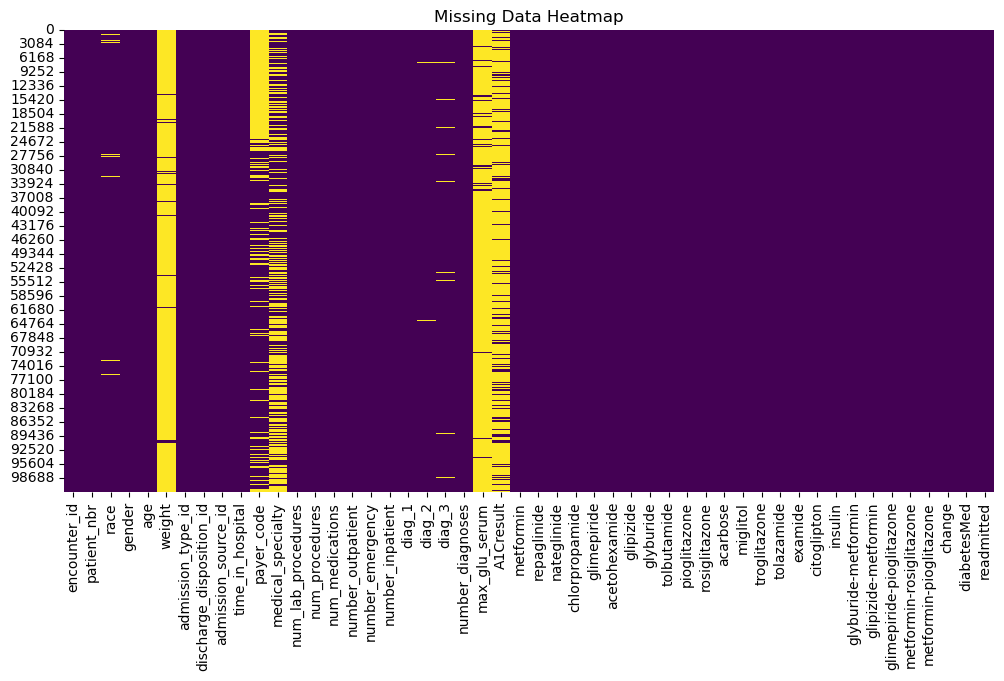

In [62]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()


## Basic statistics

In [63]:
print("\nDescriptive Statistics:")
print(df.describe(include='all'))


Descriptive Statistics:
        encounter_id   patient_nbr       race  gender      age    weight  \
count   1.017660e+05  1.017660e+05      99493  101766   101766      3197   
unique           NaN           NaN          5       3       10         9   
top              NaN           NaN  Caucasian  Female  [70-80)  [75-100)   
freq             NaN           NaN      76099   54708    26068      1336   
mean    1.652016e+08  5.433040e+07        NaN     NaN      NaN       NaN   
std     1.026403e+08  3.869636e+07        NaN     NaN      NaN       NaN   
min     1.252200e+04  1.350000e+02        NaN     NaN      NaN       NaN   
25%     8.496119e+07  2.341322e+07        NaN     NaN      NaN       NaN   
50%     1.523890e+08  4.550514e+07        NaN     NaN      NaN       NaN   
75%     2.302709e+08  8.754595e+07        NaN     NaN      NaN       NaN   
max     4.438672e+08  1.895026e+08        NaN     NaN      NaN       NaN   

        admission_type_id  discharge_disposition_id  admission

## Check target distribution

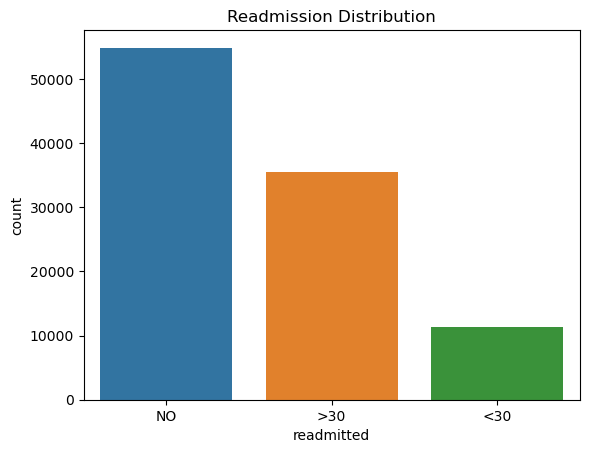

In [64]:
if 'readmitted' in df.columns:
    sns.countplot(data=df, x='readmitted')
    plt.title('Readmission Distribution')
    plt.show()
else:
    print("Target variable 'readmitted' not found.")

## Drop columns with more than 50% missing values

In [65]:

threshold = len(df) * 0.5
df.dropna(axis=1, thresh=threshold, inplace=True)


## Impute missing values

In [66]:

for column in df.columns:
    if df[column].dtype == 'object':
        df[column].fillna(df[column].mode()[0], inplace=True)
    else:
        df[column].fillna(df[column].median(), inplace=True)

## Apply mapping for nominal variables

In [67]:

for col in mapping_df['variable'].unique():
    mapping = mapping_df[mapping_df['variable'] == col].set_index('code')['category'].to_dict()
    if col in df.columns:
        df[col] = df[col].map(mapping)

## Encode categorical variables

In [68]:
label_enc = LabelEncoder()
for column in df.select_dtypes(include='object').columns:
    df[column] = label_enc.fit_transform(df[column])

## Outlier detection and treatment using IQR

In [69]:
for column in df.select_dtypes(include=['int64', 'float64']).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)

## Feature scaling

In [70]:
scaler = StandardScaler()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

## Display cleaned data info

In [71]:
print("\nCleaned Dataset Info:")
df.info()


Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   encounter_id              101766 non-null  float64
 1   patient_nbr               101766 non-null  float64
 2   race                      101766 non-null  int32  
 3   gender                    101766 non-null  int32  
 4   age                       101766 non-null  int32  
 5   admission_type_id         101766 non-null  int32  
 6   discharge_disposition_id  101766 non-null  int32  
 7   admission_source_id       101766 non-null  int32  
 8   time_in_hospital          101766 non-null  float64
 9   payer_code                101766 non-null  int32  
 10  medical_specialty         101766 non-null  int32  
 11  num_lab_procedures        101766 non-null  float64
 12  num_procedures            101766 non-null  float64
 13  num_medications      

## Visualize missing data after cleaning

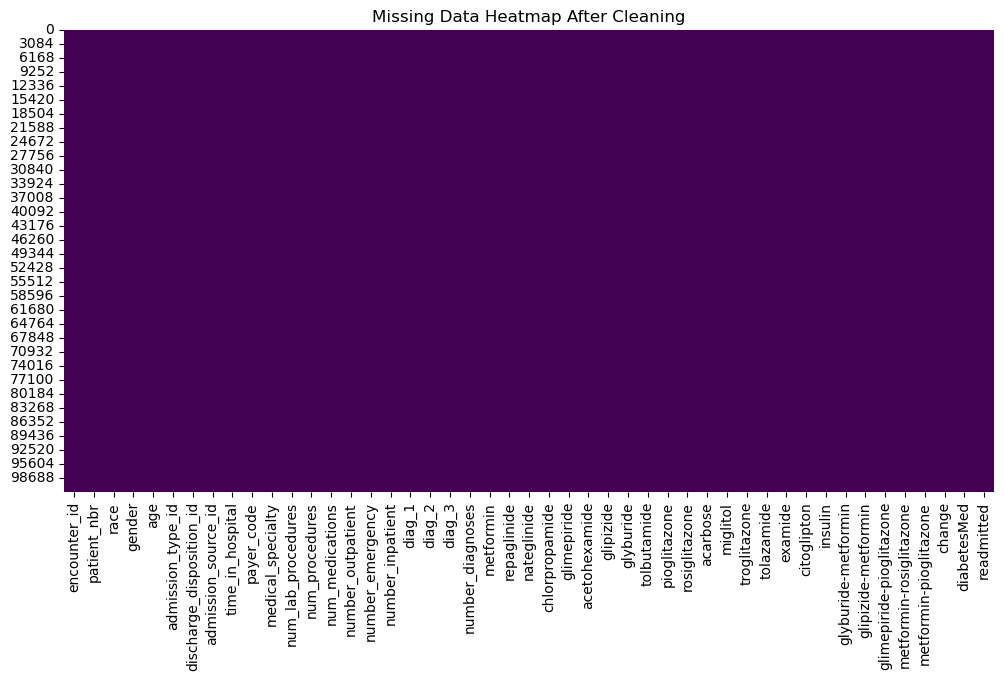

In [72]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap After Cleaning')
plt.show()

## Check target distribution after cleaning

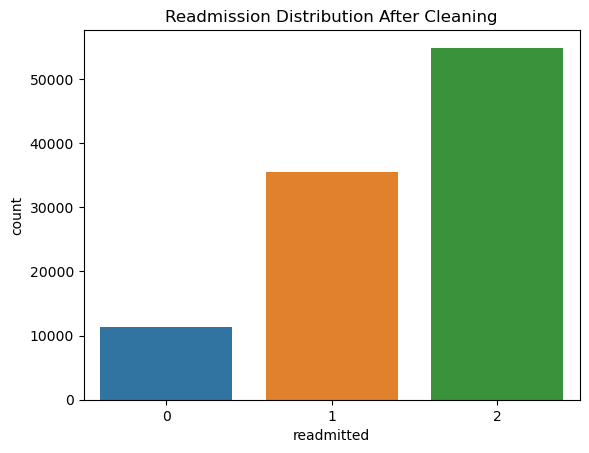

In [73]:
if 'readmitted' in df.columns:
    sns.countplot(data=df, x='readmitted')
    plt.title('Readmission Distribution After Cleaning')
    plt.show()
else:
    print("Target variable 'readmitted' not found.")


In [76]:
# Save processed data
df.to_csv("processed_data.csv", index=False)

In [ ]:
# we got 0 for <30, 1 is for >30 and 2 is for NO